# Codveda Internship: Level 1 Tasks
**Domain:** Machine Learning  
**Tasks Completed:** Task 1 (Data Preprocessing) & Task 2 (Simple Linear Regression)  
**Dataset:** Boston House Prediction Dataset








## Task 1: Data Preprocessing for Machine Learning
**Objective:** Prepare raw data for machine learning by handling missing values, encoding variables, scaling features, and splitting the dataset.

### 1. Importing Libraries 



In [77]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 2. Loading Data

In [66]:
# Define column names
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

# Load dataset (using sep='\s+' to handle spaces, replacing deprecated delim_whitespace)
df = pd.read_csv('D:\\AI\\Ai_intern\\Data Set For Task\\4) house Prediction Data Set.csv', header=None, names=column_names, sep='\\s+')

# Display the first 5 rows
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


### 2. Handling Missing Data & Categorical Variables
* **Missing Data:** We check for null values. Since the dataset is clean (`df.isnull().sum()` is 0), no dropping or mean/median imputation is required.
* **Categorical Encoding:** We check data types (`df.info()`). All features are numerical (`float64` and `int64`). Therefore, One-Hot Encoding or Label Encoding is not needed for this specific dataset.



In [67]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum().sum())

# Check data types to confirm no categorical variables exist
print("\nData Types:\n", df.dtypes.value_counts())

Missing Values:
 0

Data Types:
 float64    12
int64       2
Name: count, dtype: int64


### 3. Detecting and Handling Outliers
**Objective:** Identify and remove extreme values (outliers) that can negatively affect our Linear Regression model's performance. We will use visual Boxplots and the statistical IQR (Interquartile Range) method.




Original dataset shape: (506, 14)
Cleaned dataset shape: (238, 14)
Total outliers removed: 268 rows


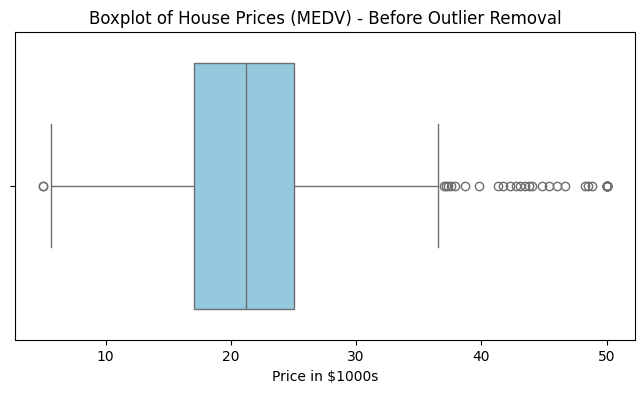

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualize outliers in the target variable (MEDV) before removal
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['MEDV'], color='skyblue')
plt.title('Boxplot of House Prices (MEDV) - Before Outlier Removal')
plt.xlabel('Price in $1000s')
# plt.show() # Uncomment to display in Jupyter

# 2. Calculate IQR (Interquartile Range) for all numerical columns
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# 3. Define the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Remove rows that have outliers in ANY column
# We keep only the rows where all values are within the bounds
df_clean = df[((df < lower_bound) | (df > upper_bound)).any(axis=1)]

# Print the result to see how many rows were removed
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Total outliers removed: {df.shape[0] - df_clean.shape[0]} rows")

### 4. Advanced Data Preprocessing (Optional but Recommended)
**Objective:** Improve the linear regression model by handling skewed data and removing highly correlated features (Multicollinearity).


C:\Users\DELL\AppData\Local\Temp\ipykernel_26164\3077868375.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['CRIM_LOG'] = np.log1p(df_clean['CRIM'])
C:\Users\DELL\AppData\Local\Temp\ipykernel_26164\3077868375.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['LSTAT_LOG'] = np.log1p(df_clean['LSTAT'])


Advanced preprocessing complete. Skewed data transformed and Multicollinearity handled.
Final dataset shape before training: (238, 13)


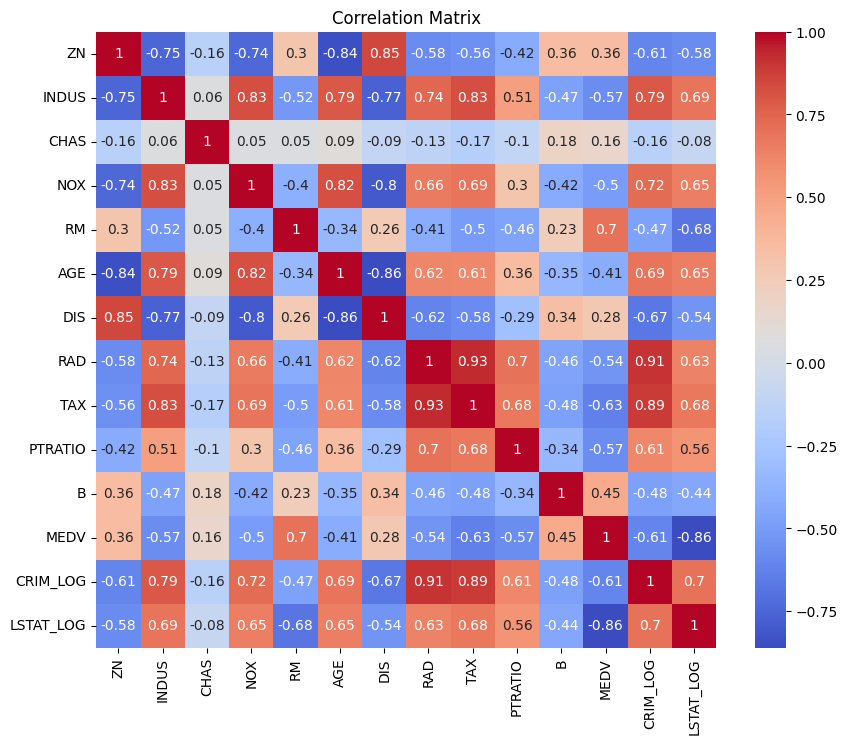

In [69]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Log Transformation for Highly Skewed Features
# Features like 'CRIM' (Crime rate) and 'LSTAT' (Lower status population) are highly skewed.
# Applying a log transformation helps them look more like a normal distribution.
# We use np.log1p() which applies log(1 + x) to handle any zero values safely.
df_clean['CRIM_LOG'] = np.log1p(df_clean['CRIM'])
df_clean['LSTAT_LOG'] = np.log1p(df_clean['LSTAT'])

# Drop the original skewed columns
df_clean = df_clean.drop(['CRIM', 'LSTAT'], axis=1)

# 2. Handling Multicollinearity (Highly Correlated Features)
# Linear regression assumes features are independent.
# Let's check the correlation between features.
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean.corr().round(2)
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
# plt.show() # Uncomment to view the heatmap

# Looking at the dataset, 'TAX' and 'RAD' are highly correlated (usually > 0.90).
# This confuses the model. We can drop 'RAD' to solve this issue.
if 'RAD' in df_clean.columns:
    df_clean = df_clean.drop('RAD', axis=1)

print("Advanced preprocessing complete. Skewed data transformed and Multicollinearity handled.")
print(f"Final dataset shape before training: {df_clean.shape}")


### 5. Splitting the Dataset
We separate the features (X) from the target continuous variable (y = MEDV) and split the data into 80% training and 20% testing sets.



In [70]:
# Separate features and target using the CLEANED data
X = df_clean.drop('MEDV', axis=1)
y = df_clean['MEDV']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 6. Normalizing / Standardizing Numerical Features
We use `StandardScaler` to standardize the features so they have a mean of 0 and a variance of 1.



In [71]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (190, 12)
Testing data shape: (48, 12)


---
## Task 2: Build a Simple Linear Regression Model
**Objective:** Train a linear regression model to predict a continuous variable (house prices), interpret its coefficients, and evaluate its performance.

### 1. Training the Model
We train a Linear Regression model using `scikit-learn` on our preprocessed training data.



In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

### 2. Evaluating the Model
We use R-squared and Mean Squared Error (MSE) to check the model's accuracy.



In [73]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 25.41
R-squared (R2): 0.82


### 3. Interpreting Model Coefficients
The coefficients indicate how each feature impacts the house price. The formula is $Y = WX + B$.
* **Positive coefficients:** Increase the house price (e.g., RM - number of rooms).
* **Negative coefficients:** Decrease the house price (e.g., LSTAT - lower status of the population).



In [74]:
# Extract Bias (Intercept)
B = model.intercept_
print(f"Bias (Intercept): {B:.4f}\n")

# Extract Weights (Coefficients)
coefficients = pd.DataFrame({
    'Feature': X.columns, 
    'Coefficient (Weight)': model.coef_
})

# Sort values to see highest and lowest impacts
print("Model Coefficients:")
print(coefficients.sort_values(by='Coefficient (Weight)', ascending=False))

Bias (Intercept): 23.8111

Model Coefficients:
      Feature  Coefficient (Weight)
5         AGE              2.132606
4          RM              1.136992
9           B              0.663504
7         TAX              0.516225
2        CHAS              0.301856
0          ZN              0.262914
8     PTRATIO             -0.974673
10   CRIM_LOG             -1.390960
3         NOX             -1.807367
1       INDUS             -1.847274
6         DIS             -4.125175
11  LSTAT_LOG             -9.476891
